In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("E:/Python/MSc_Project_Upgrade/")
sys.path.append(str(PROJECT_ROOT))

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import time
 
from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from utils.modelarch import JetViT
 
# ── paths ─────────────────────────────────────────────────────────
CKPT_PATH   = PROJECT_ROOT / "results_analysis/vit/ViT_model2_250GeV/ViT_model2_250GeV.pt"
TEST_DIR    = PROJECT_ROOT / "datasets/cnn_vit"
RESULT_DIR  = PROJECT_ROOT / "results_analysis/vit/test_results_model2_250GeV"

RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
ENERGIES  = [100, 125, 150, 200, 250, 300]
THRESHOLD = 0.5
 
# ── ViT architecture (must match training config exactly) ─────────
VIT_CFG = {
    "patch_size" : 4,
    "emb_dim"    : 128,
    "depth"      : 4,
    "num_heads"  : 4,
    "mlp_dim"    : 256,
    "dropout"    : 0.1,
}
 
# ── log helper ────────────────────────────────────────────────────
log_lines = []
def rlog(*args):
    line = " ".join(str(a) for a in args)
    print(line)
    log_lines.append(line)
 
def rsep(n=60): rlog("=" * n)
 
# ── device ────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rlog(f"Device : {device}")
 
# ── load model ────────────────────────────────────────────────────
model = JetViT(
    input_shape = (3, 32, 32),
    patch_size  = VIT_CFG["patch_size"],
    emb_dim     = VIT_CFG["emb_dim"],
    depth       = VIT_CFG["depth"],
    num_heads   = VIT_CFG["num_heads"],
    mlp_dim     = VIT_CFG["mlp_dim"],
    dropout     = VIT_CFG["dropout"]
).to(device)
 
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
rlog(f"Loaded  : ViT_model2_250GeV.pt")
rlog(f"Epoch   : {ckpt['epoch']+1}  |  Val AUC (train) : {ckpt['val_auc']:.4f}")

Device : cpu
Loaded  : ViT_model2_250GeV.pt
Epoch   : 44  |  Val AUC (train) : 0.9988


In [ ]:
def run_inference(model, images_np, device, batch_size=512):
    scores = []
    with torch.no_grad():
        for start in range(0, len(images_np), batch_size):
            batch = torch.tensor(images_np[start:start+batch_size],
                                 dtype=torch.float32).to(device)
            probs = torch.sigmoid(model(batch)).cpu().numpy()
            scores.append(probs)
    return np.concatenate(scores)
 
 
def pt_binned_efficiency(pt, scores, mask, threshold, pt_bins):
    eff, err, bc = [], [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        sel = mask & (pt >= lo) & (pt < hi)
        n   = sel.sum()
        if n == 0: continue
        k = (scores[sel] > threshold).sum()
        e = k / n
        eff.append(e)
        err.append(np.sqrt(e * (1 - e) / n))
        bc.append(0.5 * (lo + hi))
    return np.array(bc), np.array(eff), np.array(err)

  Evaluating 100 GeV
  Jets loaded  : 224164
  Signal (tau) : 46519
  Bkg (jj)     : 86667
  Bkg (bb)     : 90978
  Inference : 360.4s


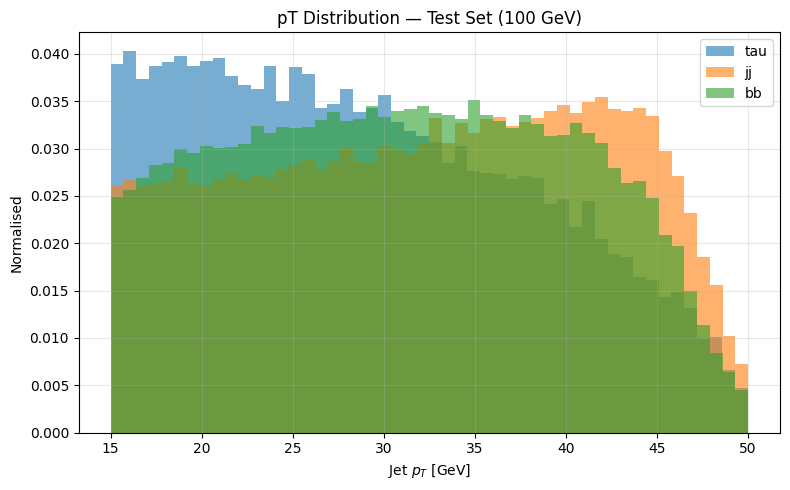

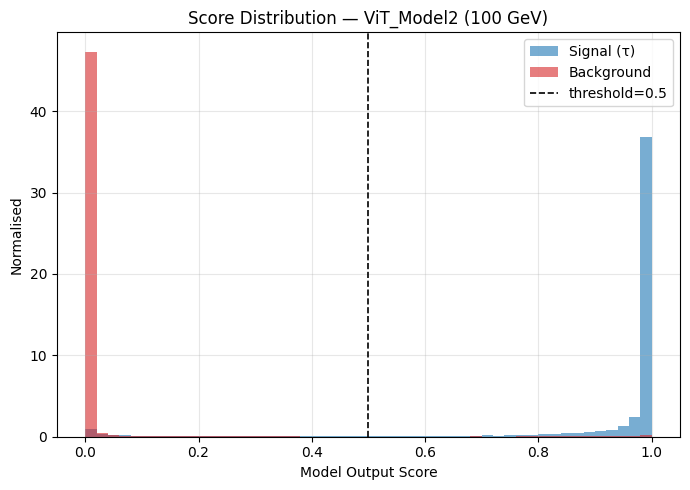


  ── Metrics (threshold=0.5) ──
  Accuracy  : 0.9693
  Precision : 0.9262
  Recall    : 0.9258
  F1        : 0.9260
  AUC       : 0.9937
  AUC τ vs jj : 0.9896
  AUC τ vs bb : 0.9977


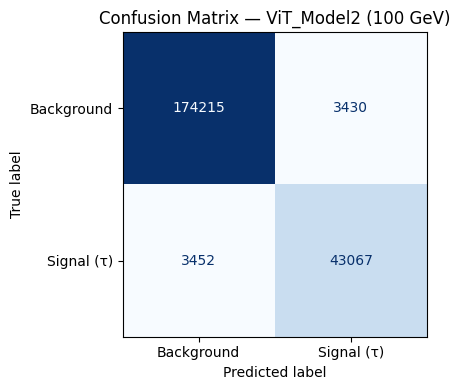

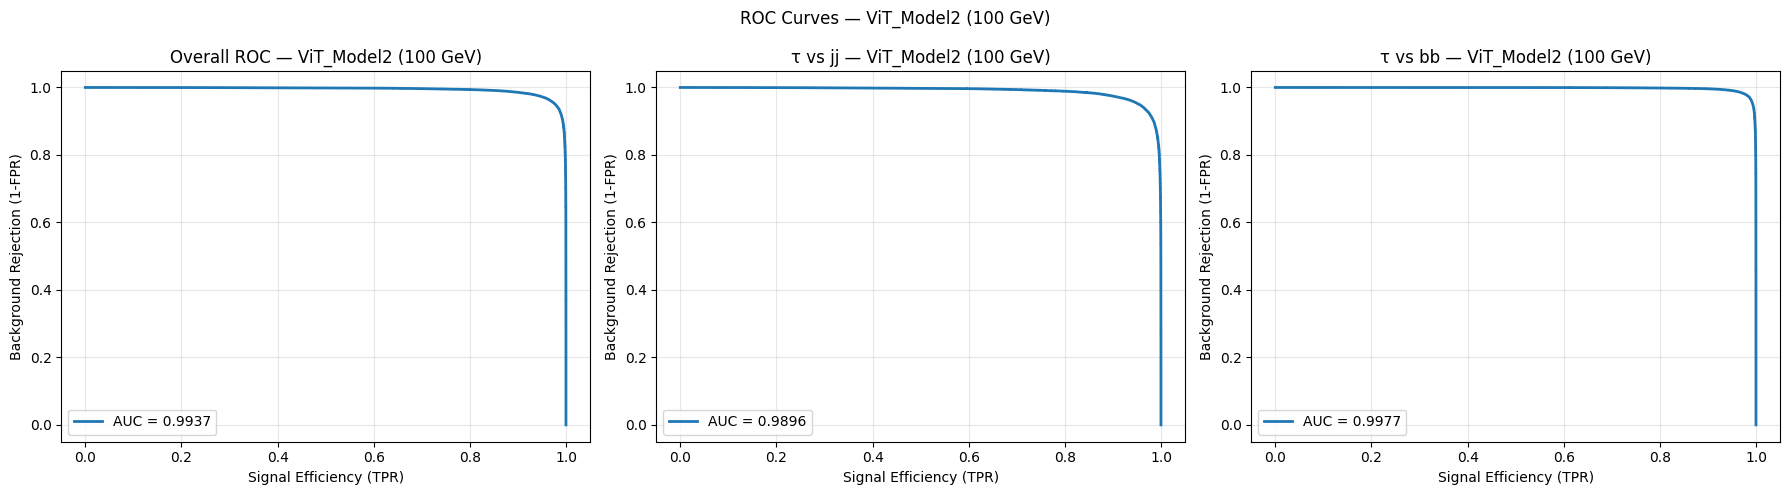

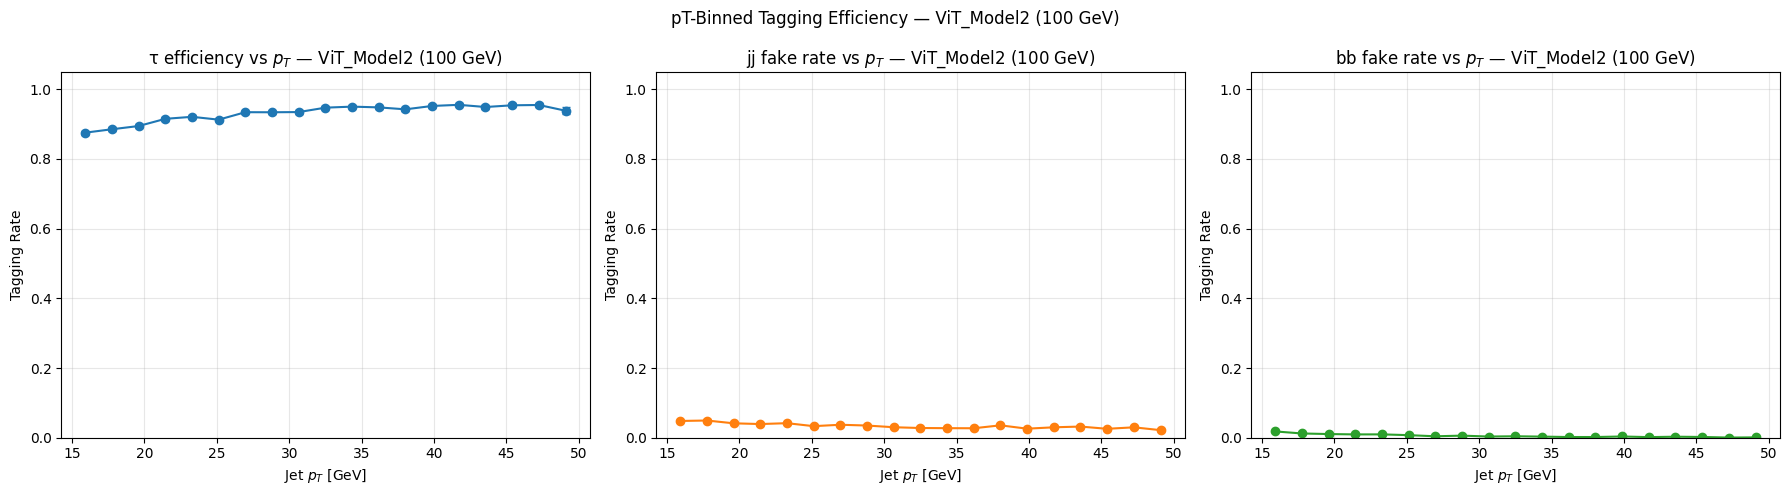

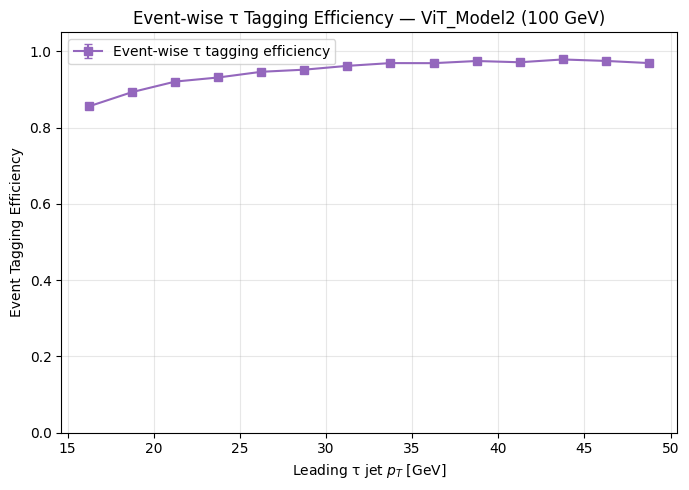


  Event-tagging efficiency : 0.9444  (32367/34274 events)

  ── Jet-level tagging completeness ──
  Mean completeness          : 0.9230
  Fraction fully tagged      : 0.9016  (30901/34274 events)
  Fraction not tagged at all : 0.0556  (1907/34274 events)


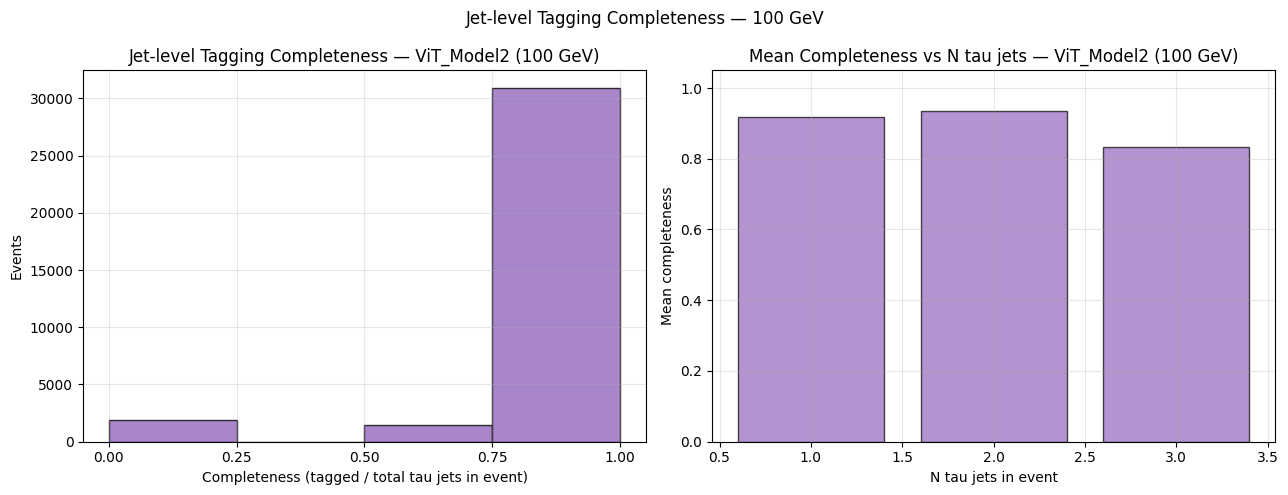


  Plots saved to: E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV\100GeV
  Evaluating 125 GeV
  Jets loaded  : 239720
  Signal (tau) : 50874
  Bkg (jj)     : 92467
  Bkg (bb)     : 96379
  Inference : 360.4s


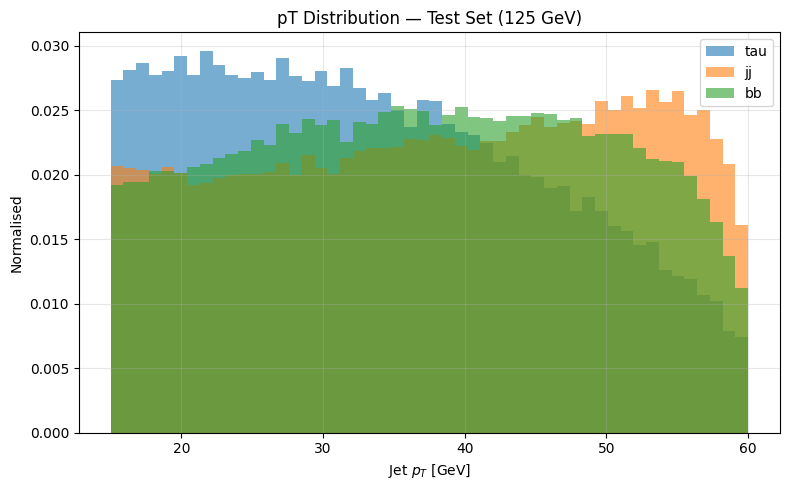

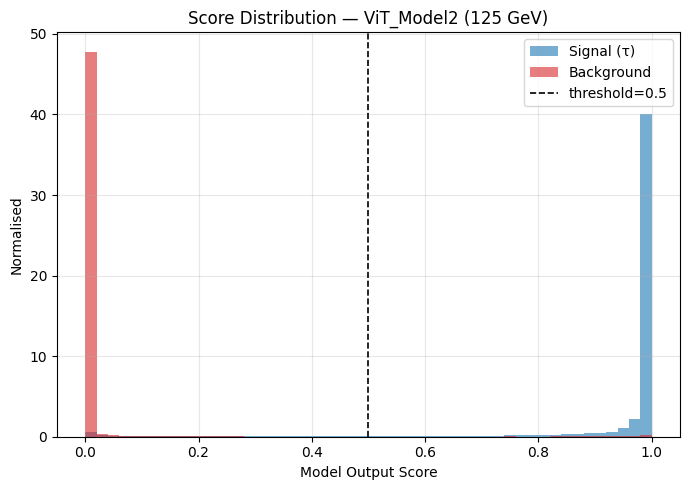


  ── Metrics (threshold=0.5) ──
  Accuracy  : 0.9774
  Precision : 0.9407
  Recall    : 0.9537
  F1        : 0.9472
  AUC       : 0.9963
  AUC τ vs jj : 0.9939
  AUC τ vs bb : 0.9986


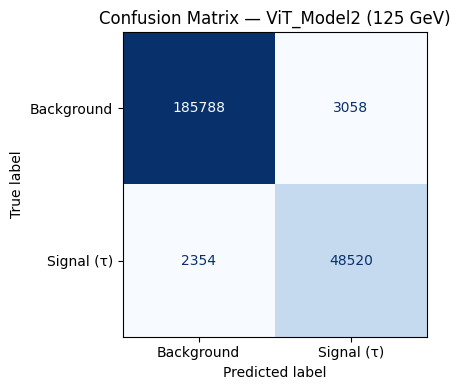

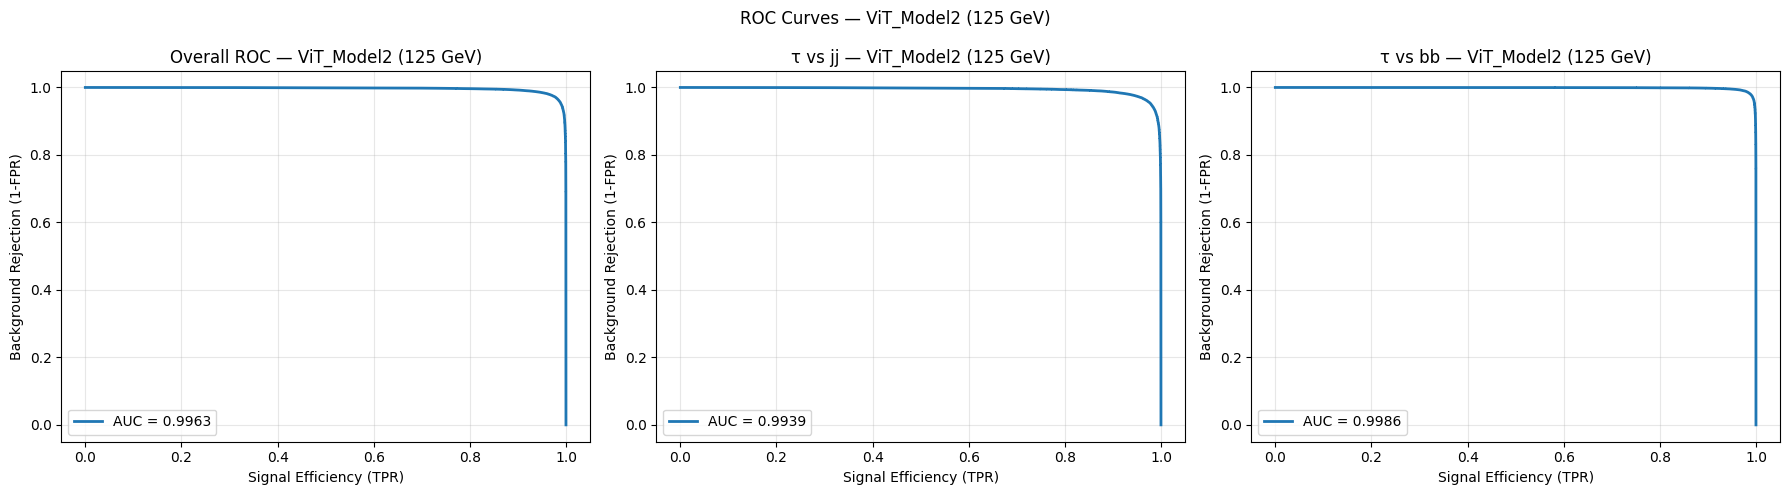

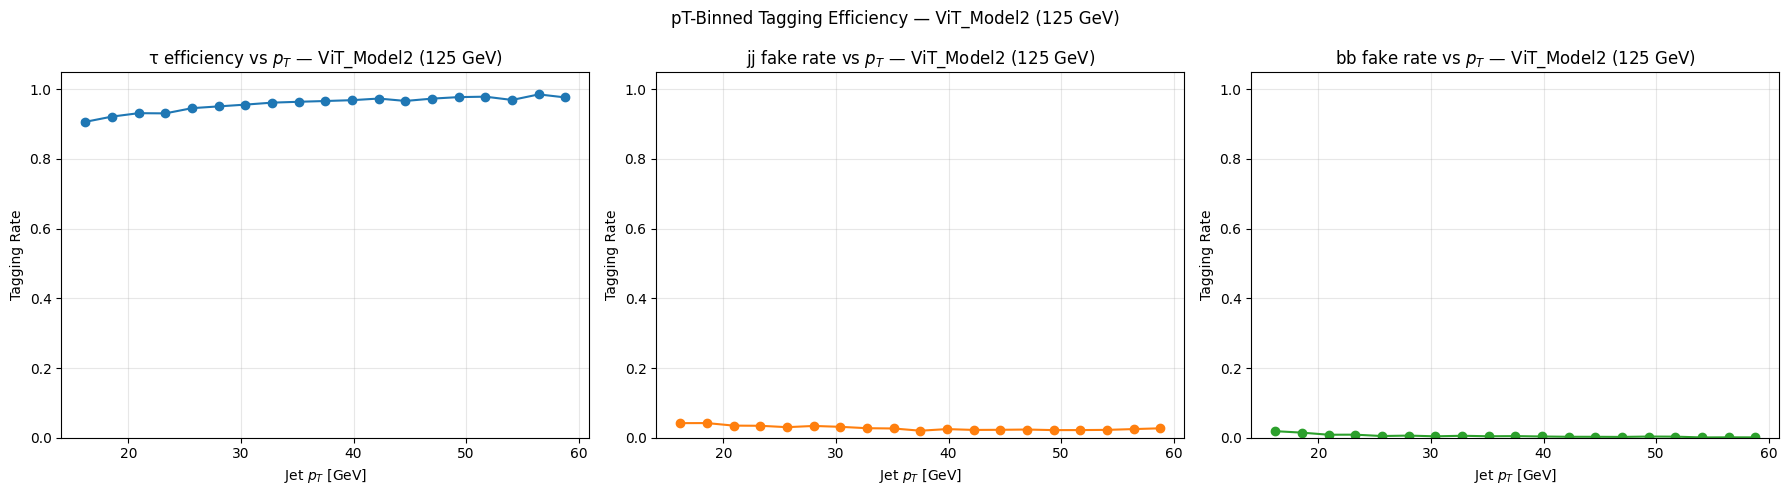

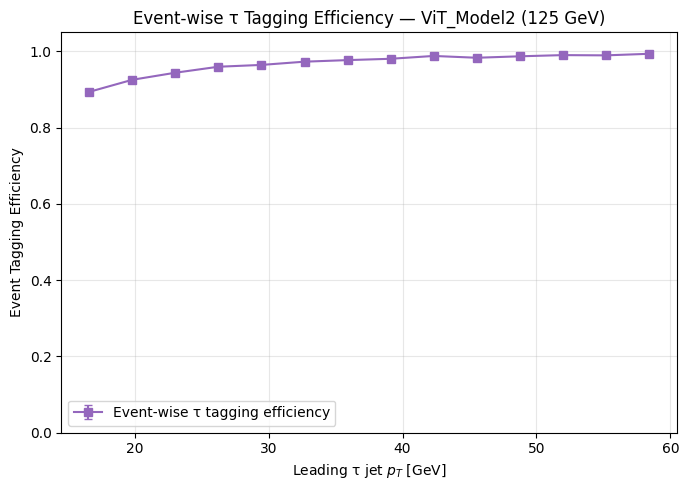


  Event-tagging efficiency : 0.9665  (35640/36874 events)

  ── Jet-level tagging completeness ──
  Mean completeness          : 0.9520
  Fraction fully tagged      : 0.9373  (34563/36874 events)
  Fraction not tagged at all : 0.0335  (1234/36874 events)


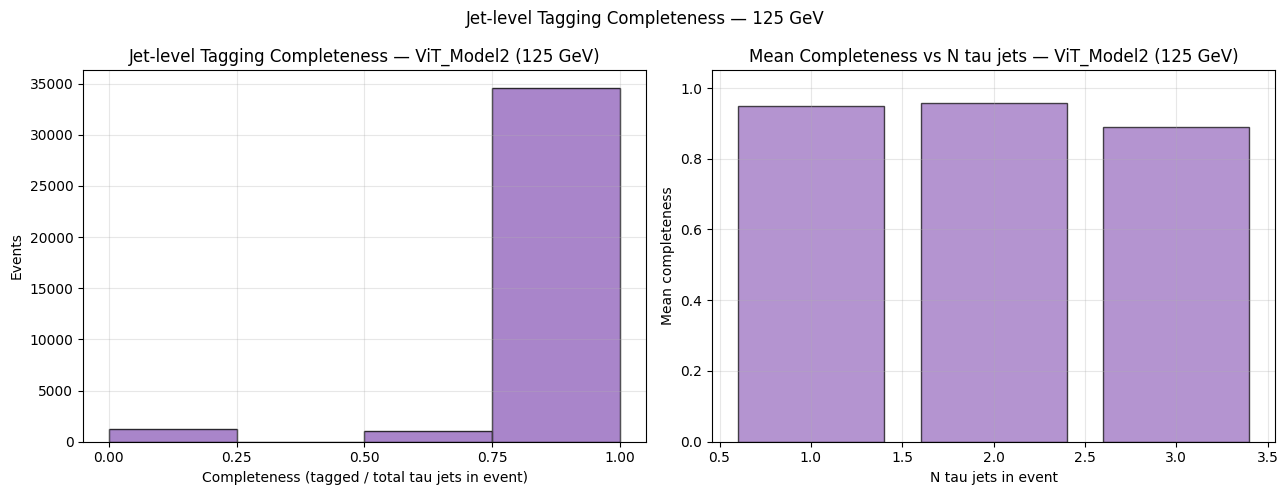


  Plots saved to: E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV\125GeV
  Evaluating 150 GeV
  Jets loaded  : 258279
  Signal (tau) : 54839
  Bkg (jj)     : 100831
  Bkg (bb)     : 102609
  Inference : 445.4s


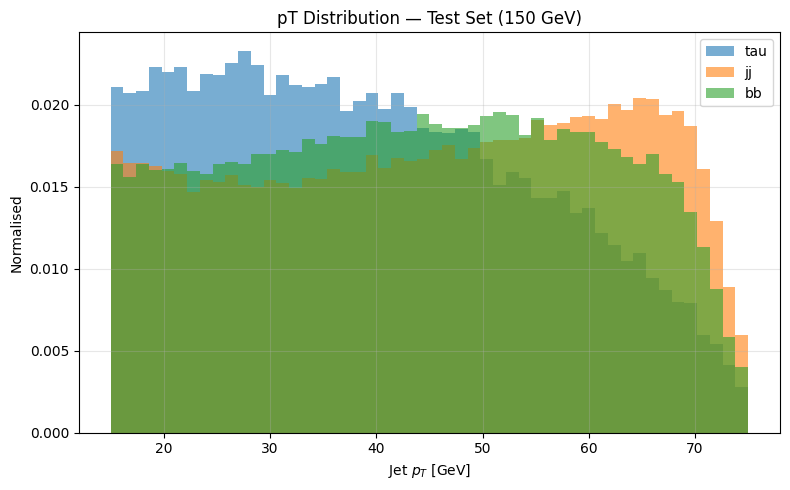

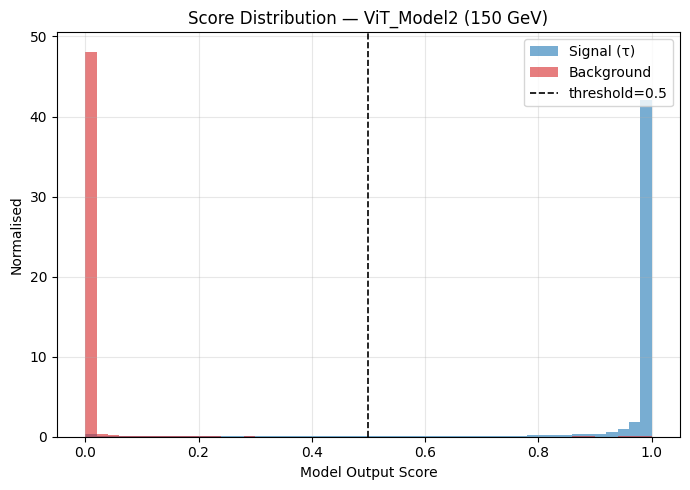


  ── Metrics (threshold=0.5) ──
  Accuracy  : 0.9820
  Precision : 0.9499
  Recall    : 0.9660
  F1        : 0.9579
  AUC       : 0.9976
  AUC τ vs jj : 0.9959
  AUC τ vs bb : 0.9992


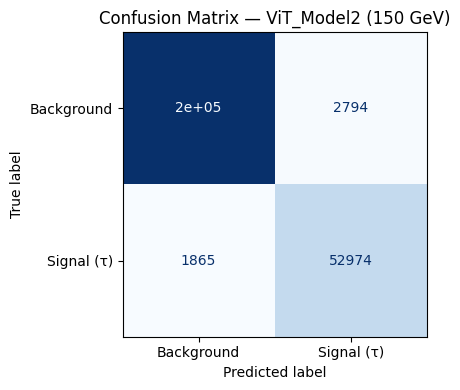

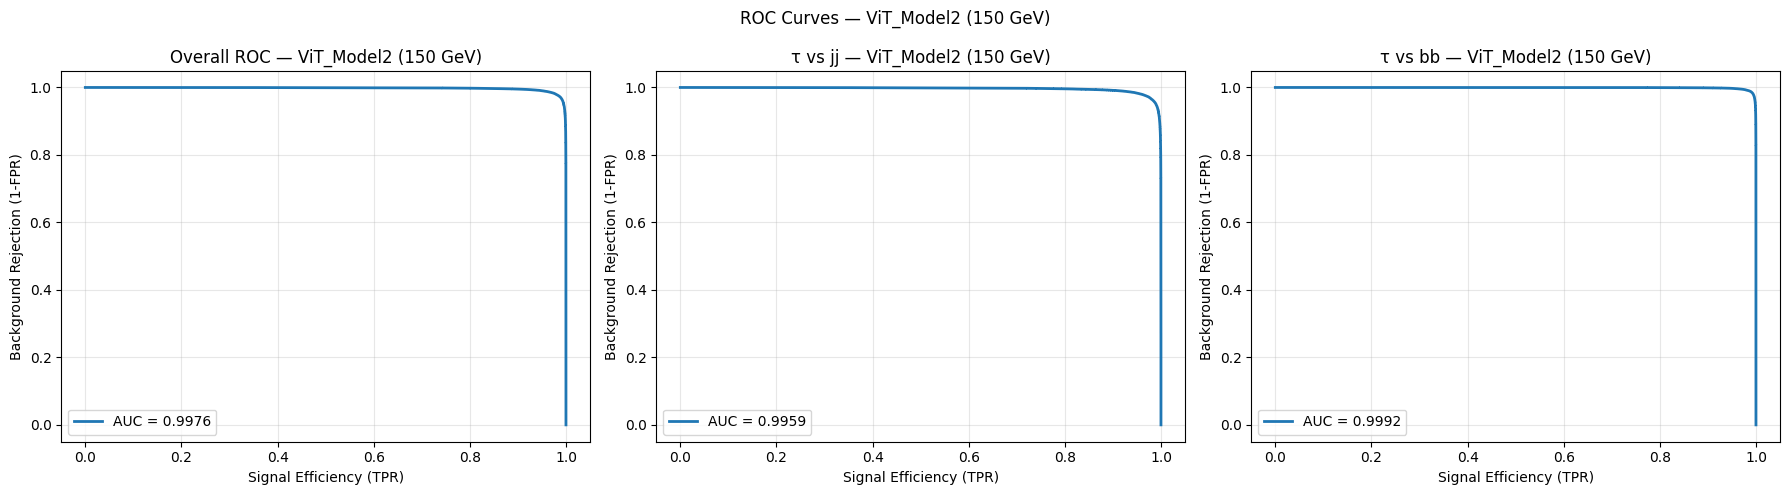

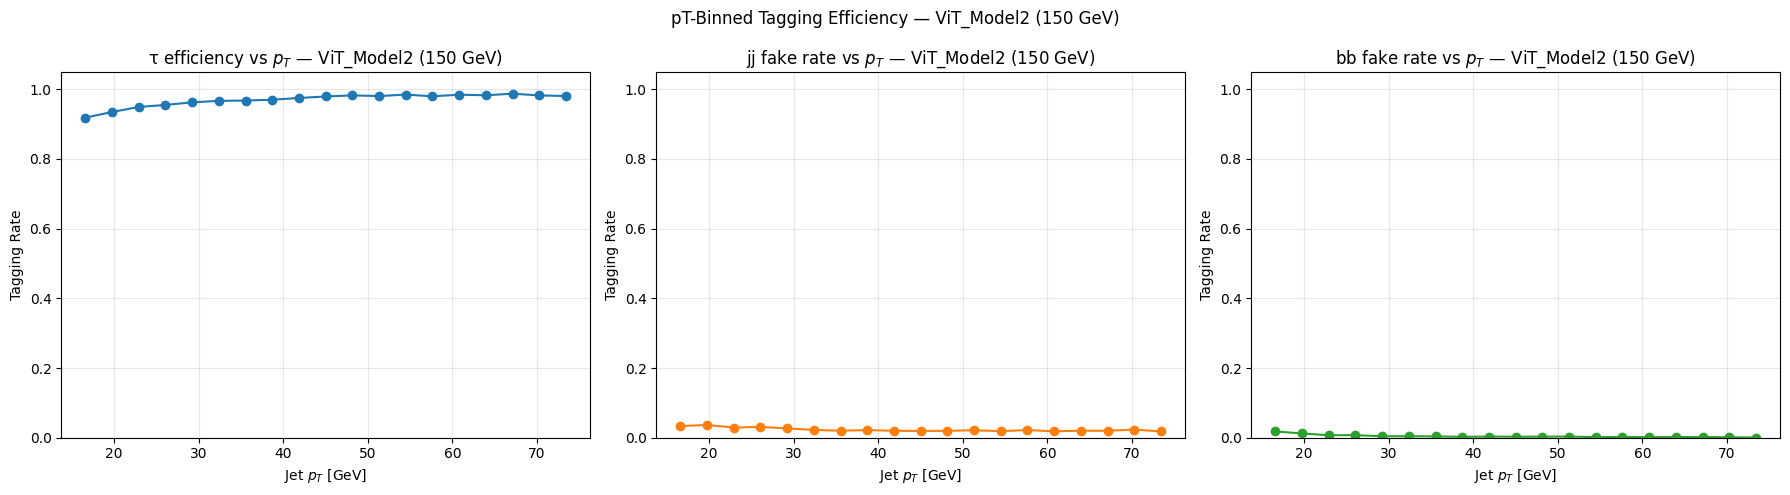

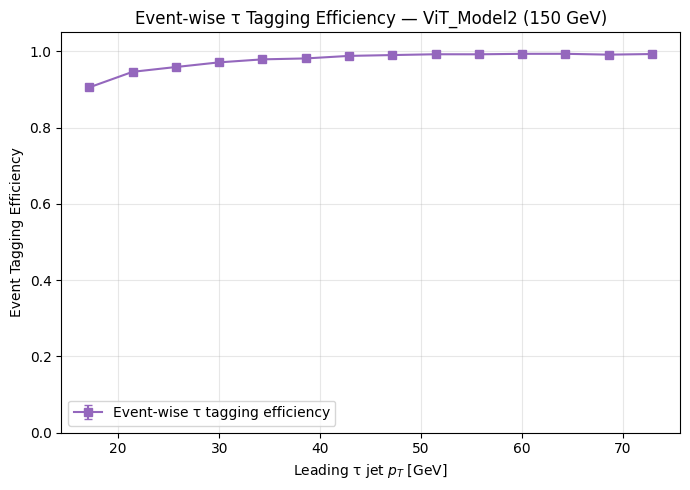


  Event-tagging efficiency : 0.9762  (37962/38889 events)

  ── Jet-level tagging completeness ──
  Mean completeness          : 0.9644
  Fraction fully tagged      : 0.9527  (37049/38889 events)
  Fraction not tagged at all : 0.0238  (927/38889 events)


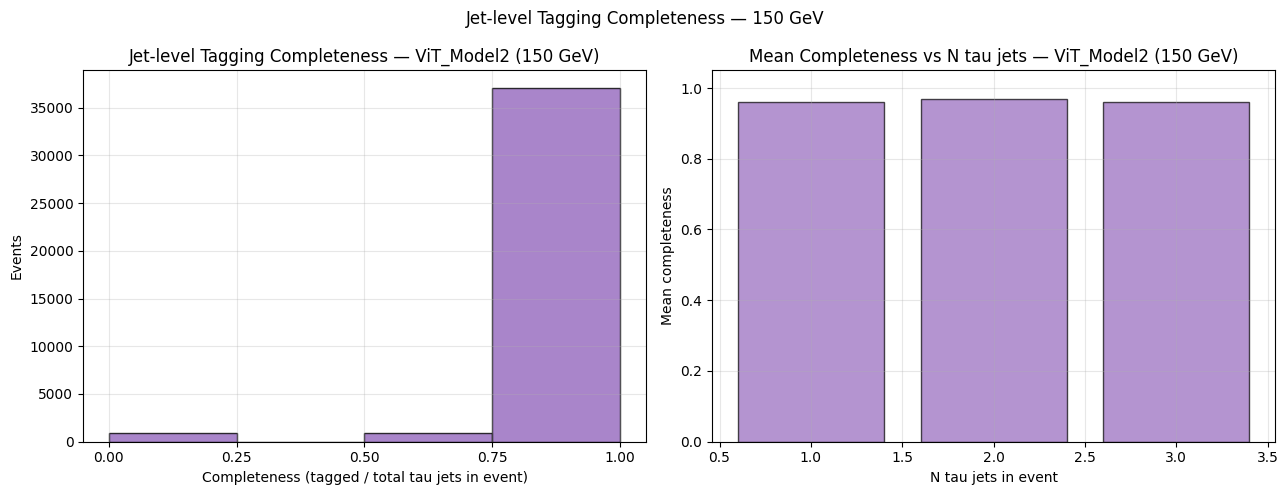


  Plots saved to: E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV\150GeV
  Evaluating 200 GeV
  Jets loaded  : 277990
  Signal (tau) : 58709
  Bkg (jj)     : 109259
  Bkg (bb)     : 110022
  Inference : 699.7s


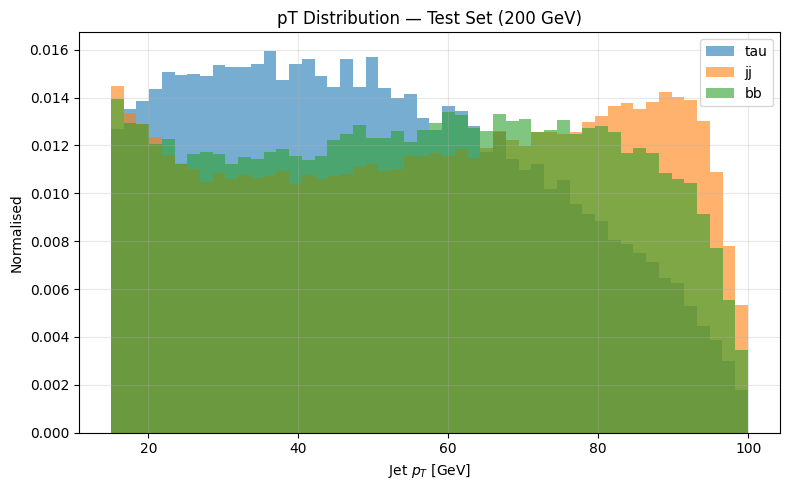

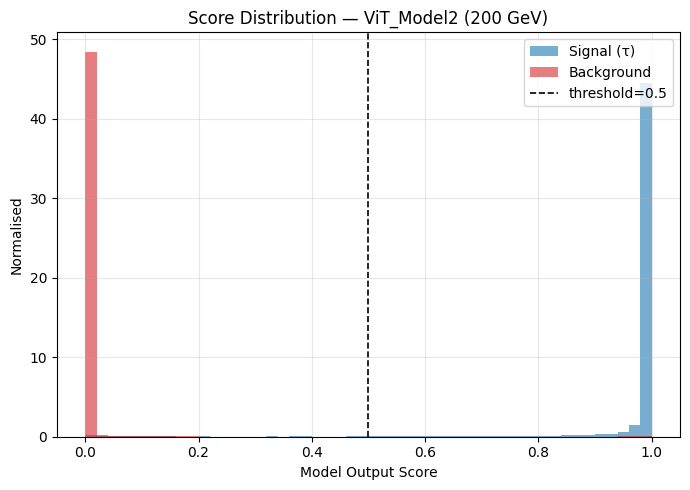


  ── Metrics (threshold=0.5) ──
  Accuracy  : 0.9872
  Precision : 0.9589
  Recall    : 0.9815
  F1        : 0.9701
  AUC       : 0.9986
  AUC τ vs jj : 0.9976
  AUC τ vs bb : 0.9995


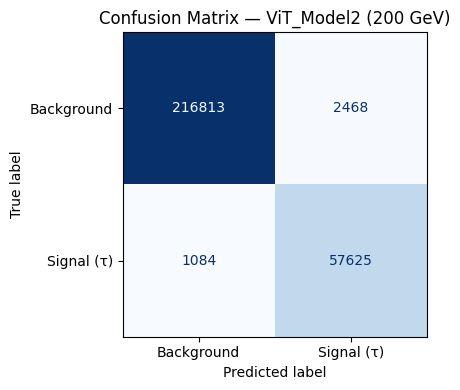

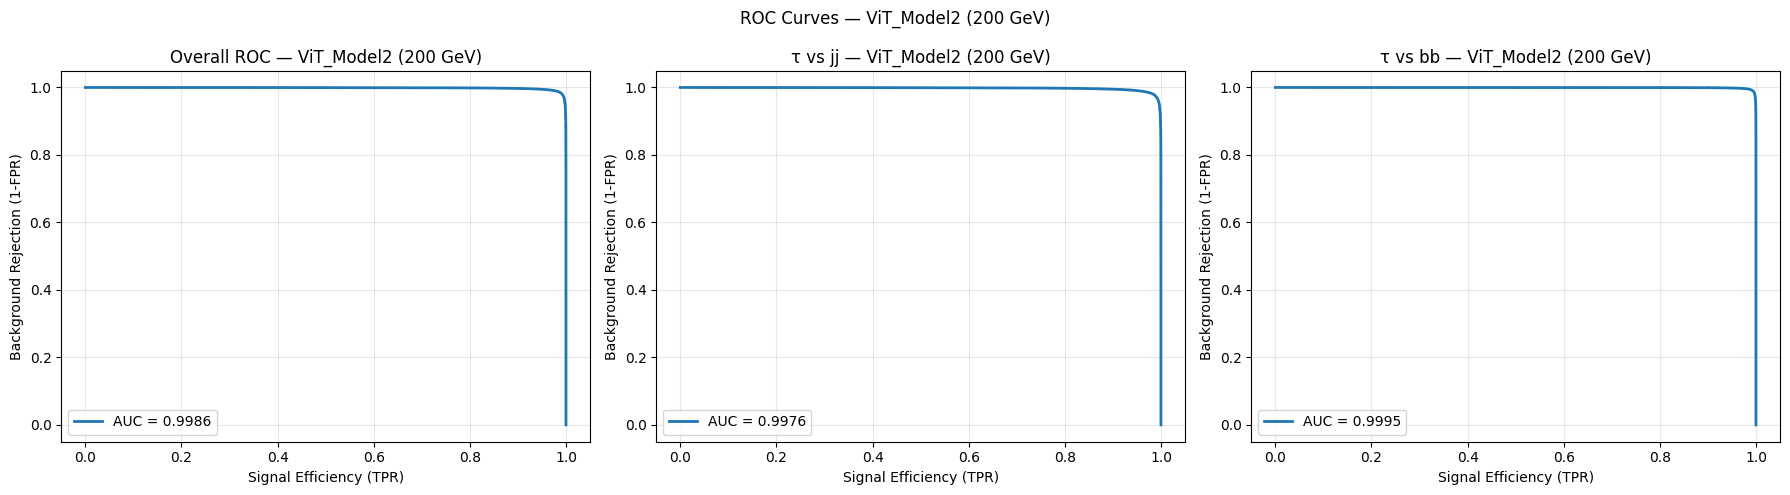

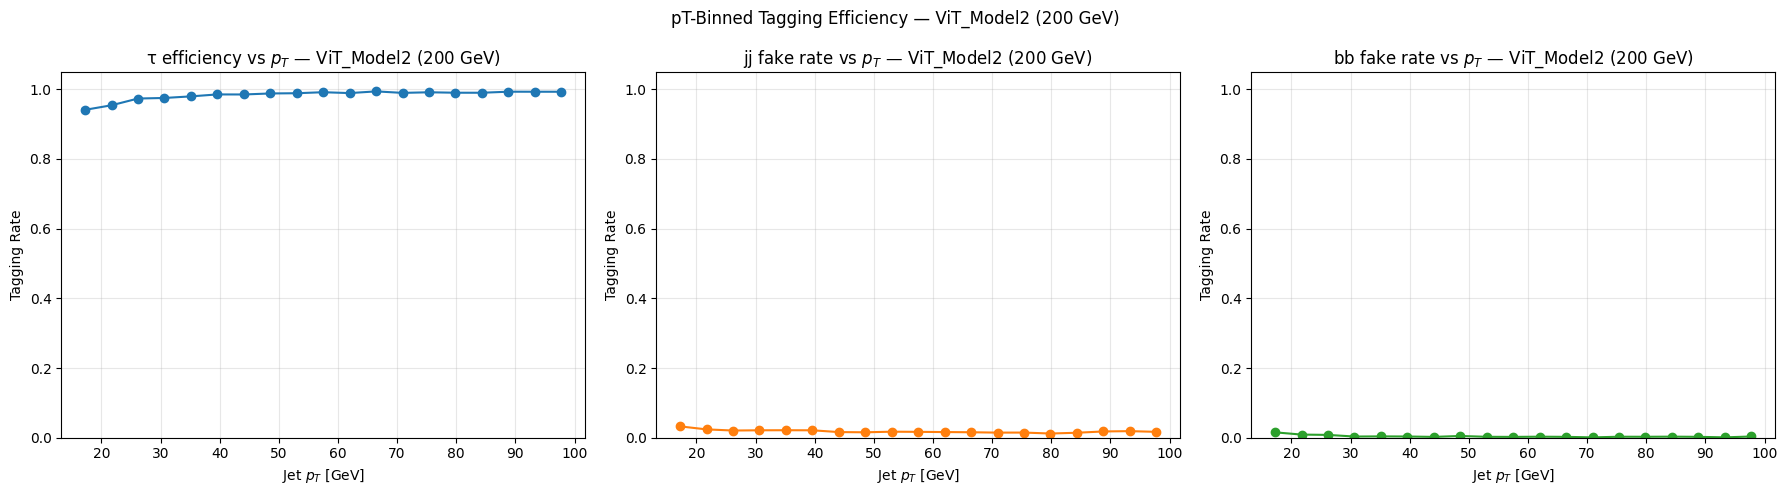

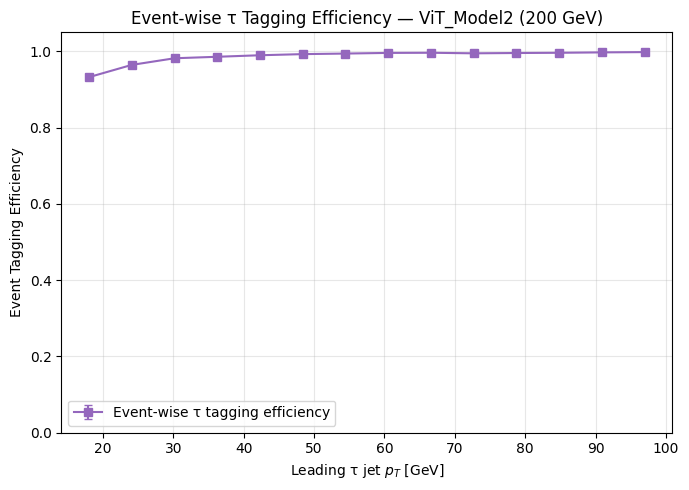


  Event-tagging efficiency : 0.9873  (40341/40859 events)

  ── Jet-level tagging completeness ──
  Mean completeness          : 0.9806
  Fraction fully tagged      : 0.9739  (39792/40859 events)
  Fraction not tagged at all : 0.0127  (518/40859 events)


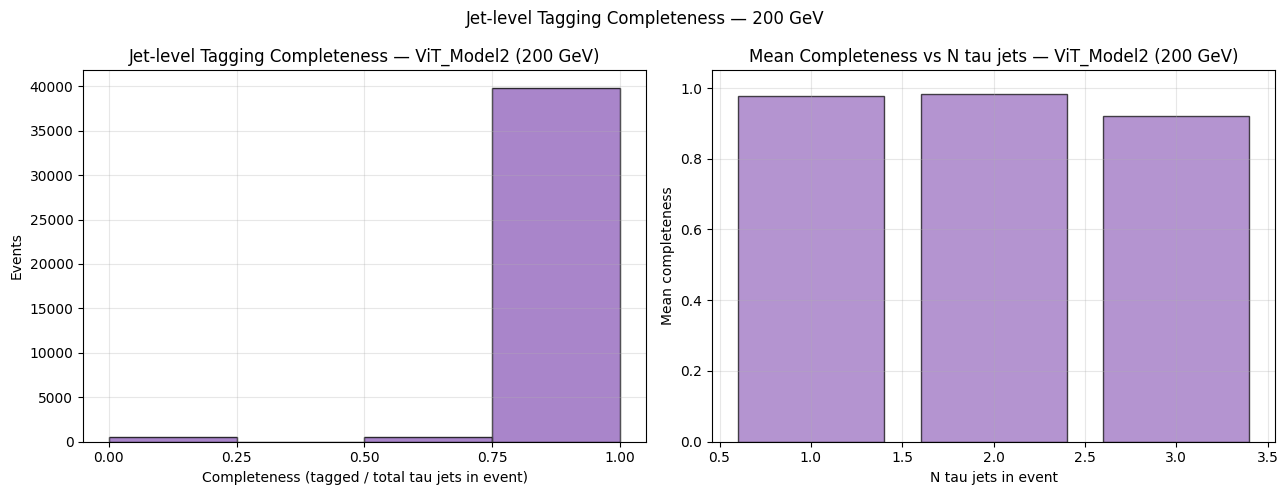


  Plots saved to: E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV\200GeV
  Evaluating 250 GeV
  Jets loaded  : 291519
  Signal (tau) : 60697
  Bkg (jj)     : 115093
  Bkg (bb)     : 115729
  Inference : 687.1s


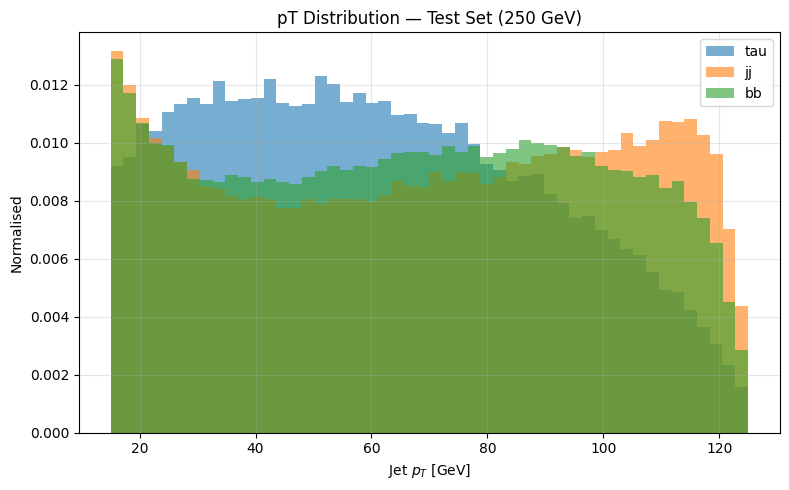

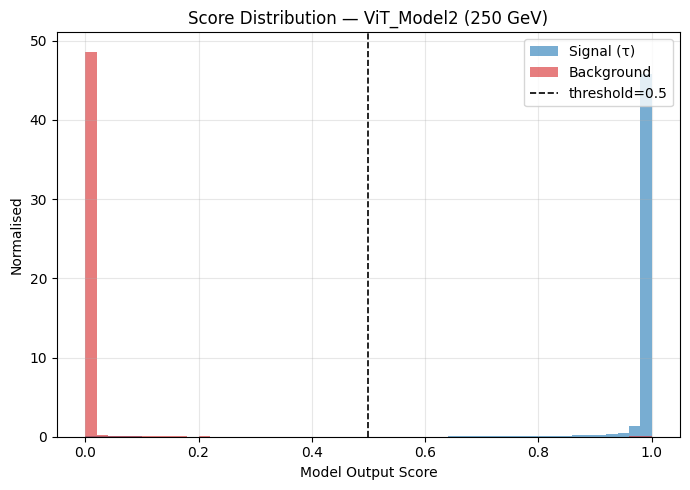


  ── Metrics (threshold=0.5) ──
  Accuracy  : 0.9891
  Precision : 0.9620
  Recall    : 0.9868
  F1        : 0.9742
  AUC       : 0.9989
  AUC τ vs jj : 0.9983
  AUC τ vs bb : 0.9996


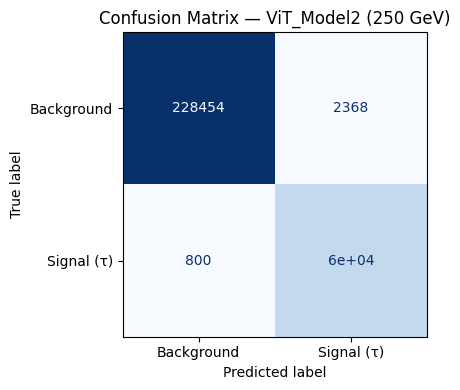

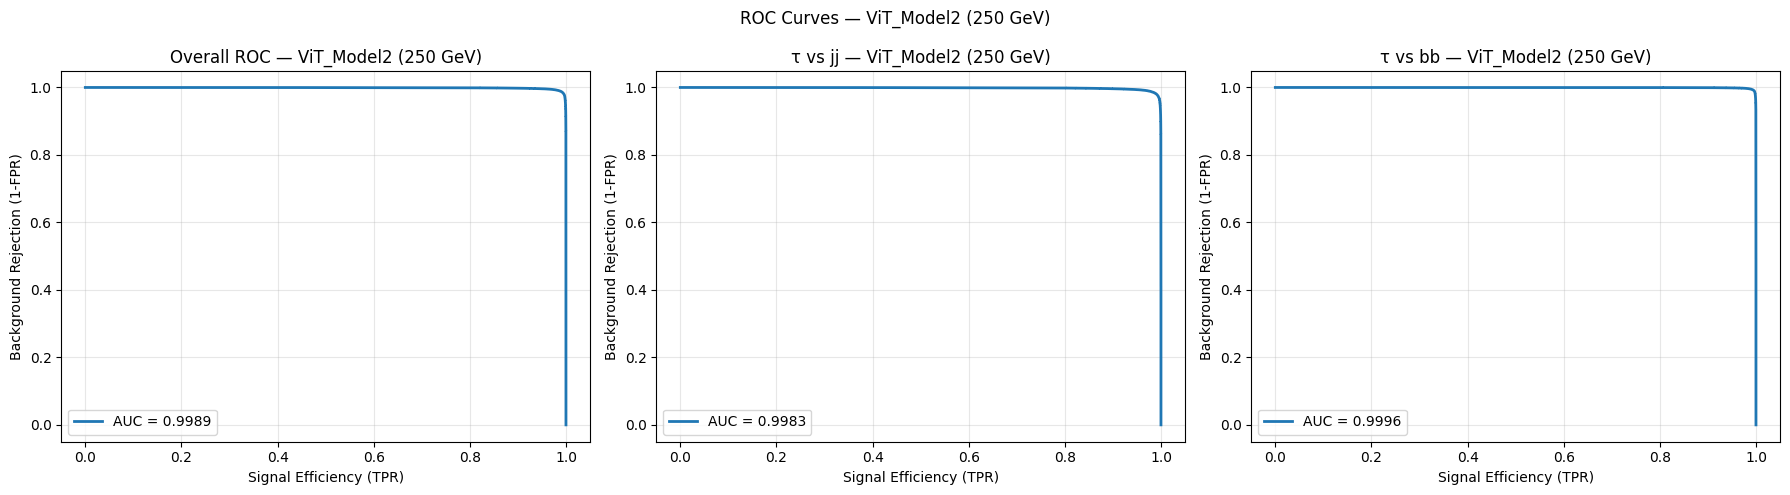

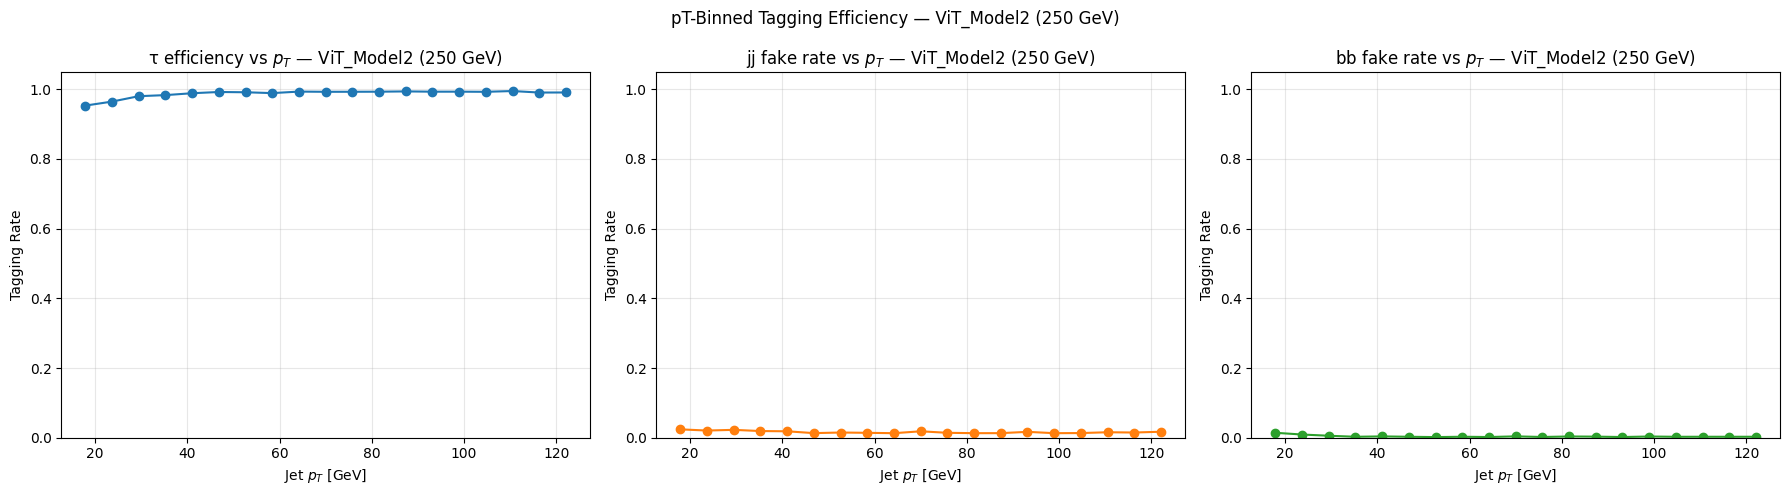

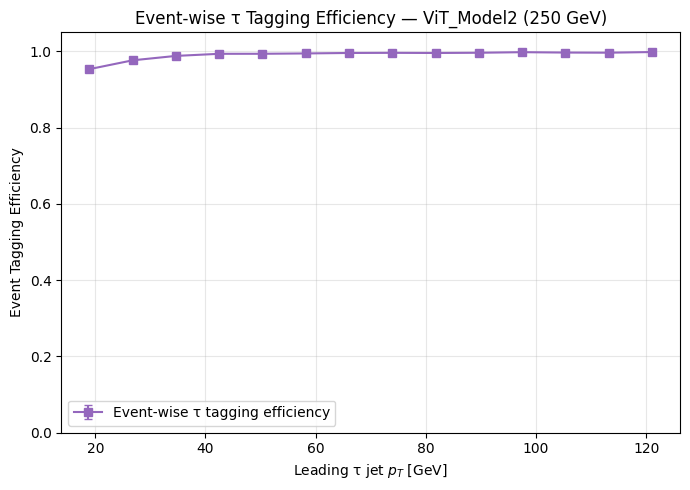


  Event-tagging efficiency : 0.9916  (41544/41898 events)

  ── Jet-level tagging completeness ──
  Mean completeness          : 0.9864
  Fraction fully tagged      : 0.9812  (41109/41898 events)
  Fraction not tagged at all : 0.0084  (354/41898 events)


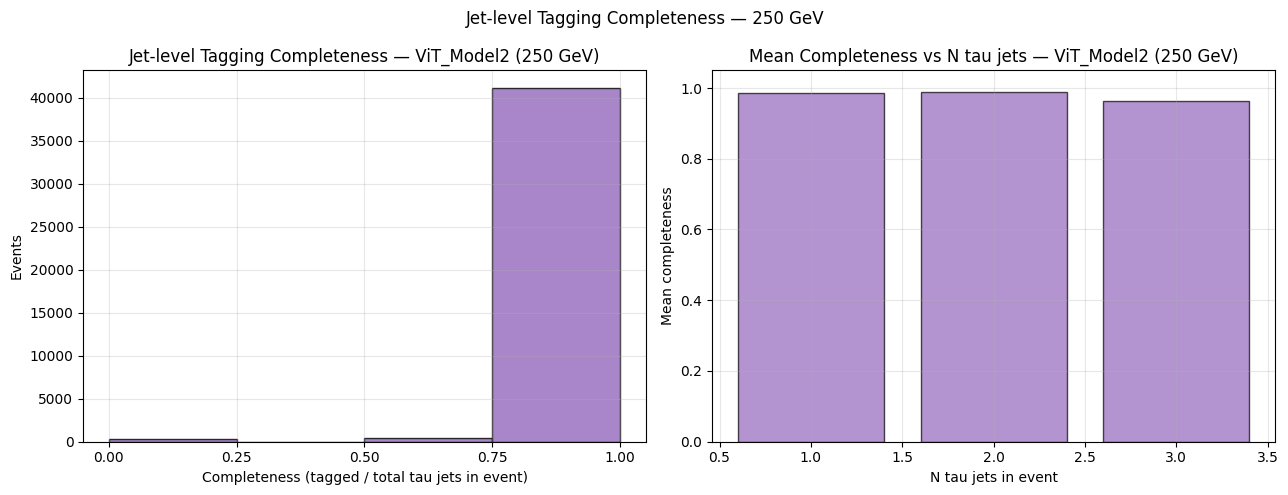


  Plots saved to: E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV\250GeV
  Evaluating 300 GeV
  Jets loaded  : 302466
  Signal (tau) : 61871
  Bkg (jj)     : 120093
  Bkg (bb)     : 120502
  Inference : 422.4s


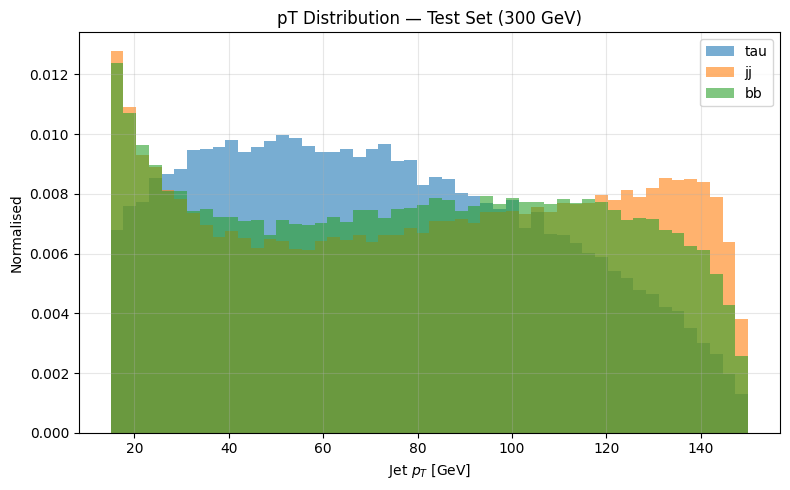

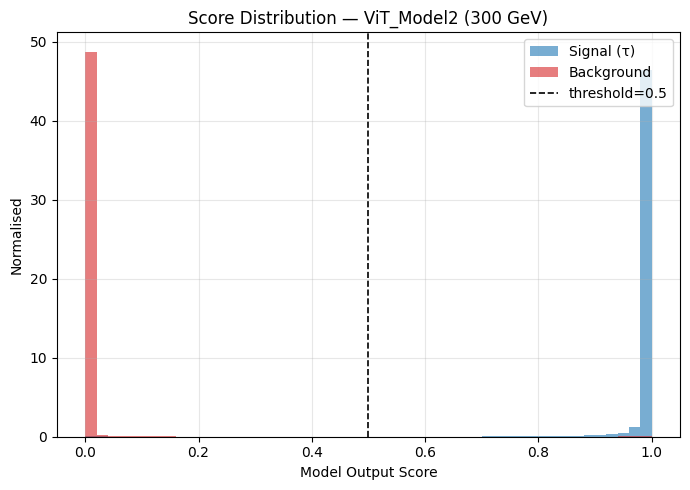


  ── Metrics (threshold=0.5) ──
  Accuracy  : 0.9906
  Precision : 0.9644
  Recall    : 0.9908
  F1        : 0.9774
  AUC       : 0.9991
  AUC τ vs jj : 0.9986
  AUC τ vs bb : 0.9996


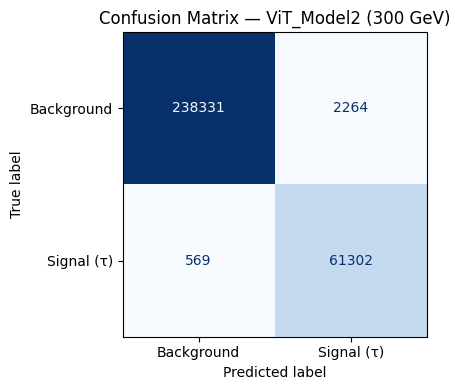

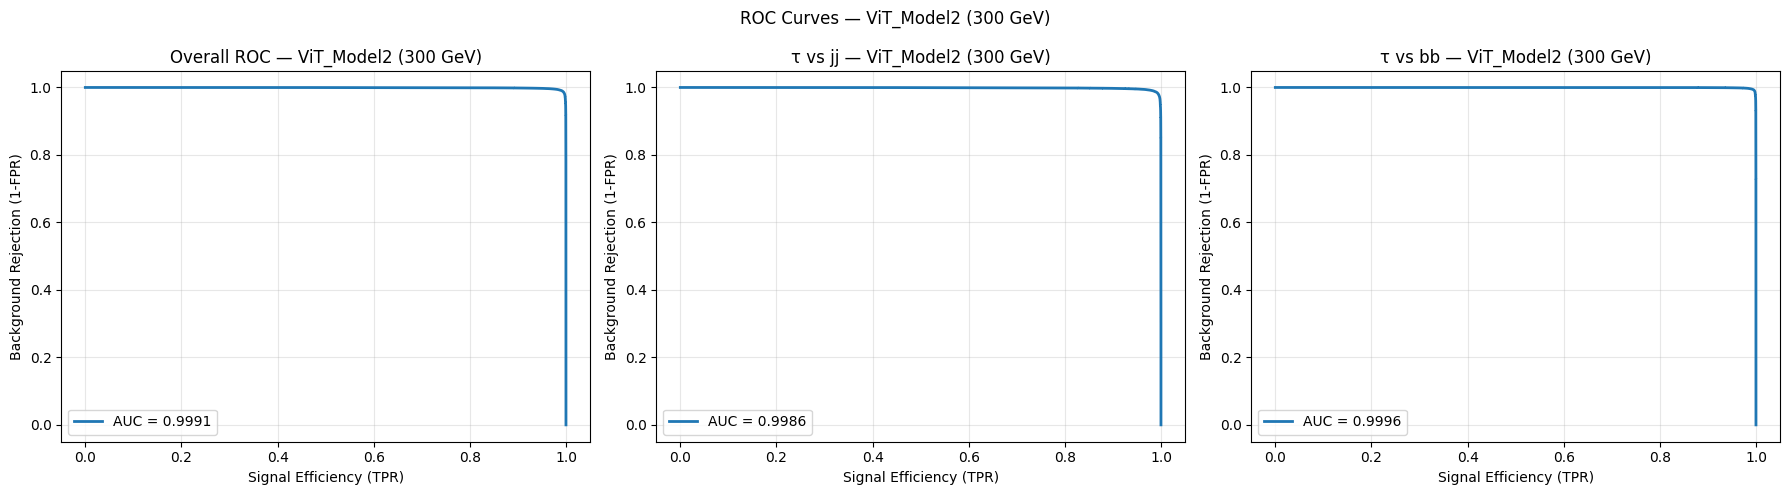

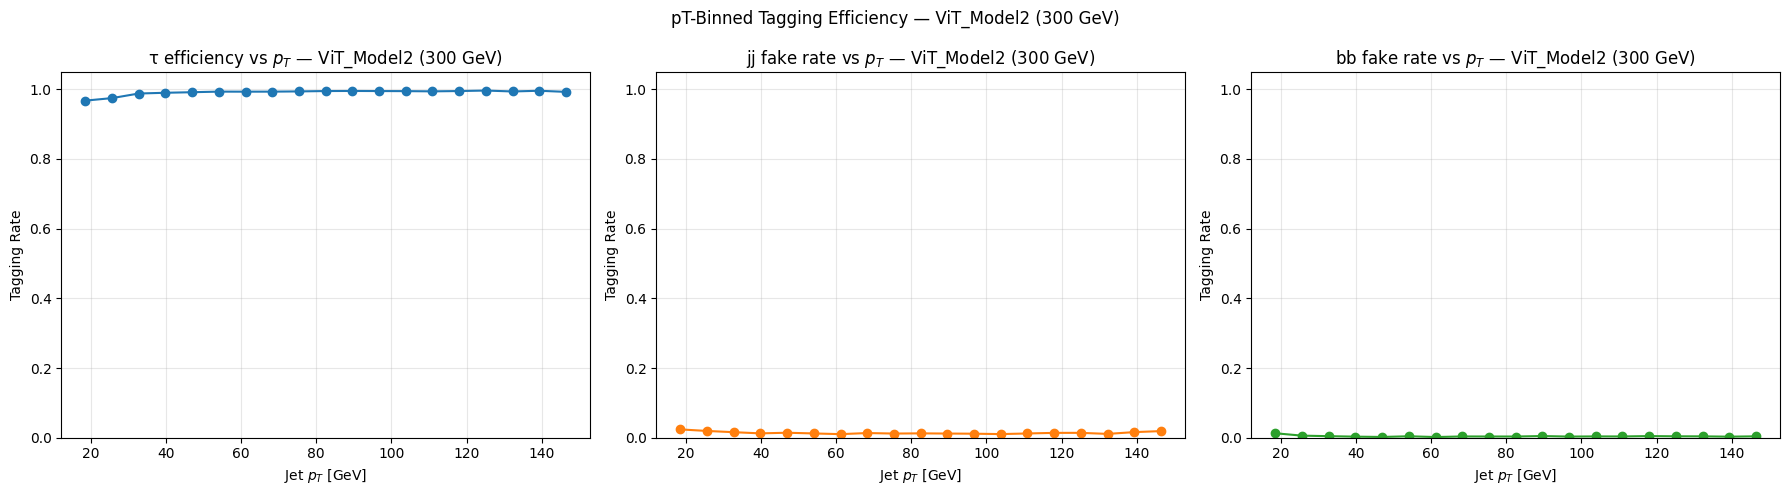

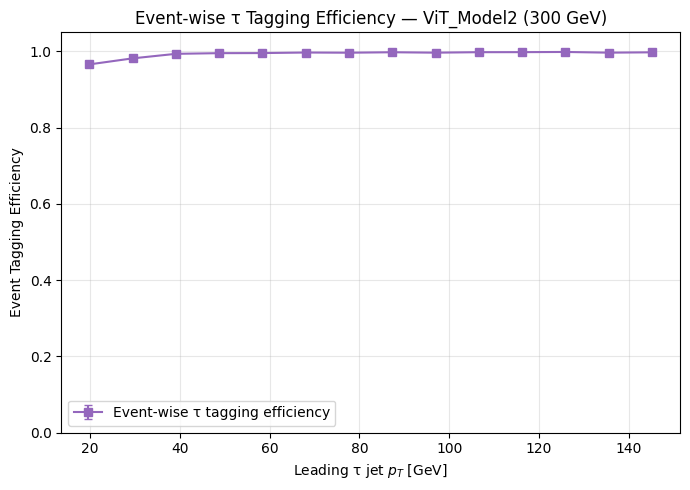


  Event-tagging efficiency : 0.9942  (42147/42394 events)

  ── Jet-level tagging completeness ──
  Mean completeness          : 0.9905
  Fraction fully tagged      : 0.9867  (41830/42394 events)
  Fraction not tagged at all : 0.0058  (247/42394 events)


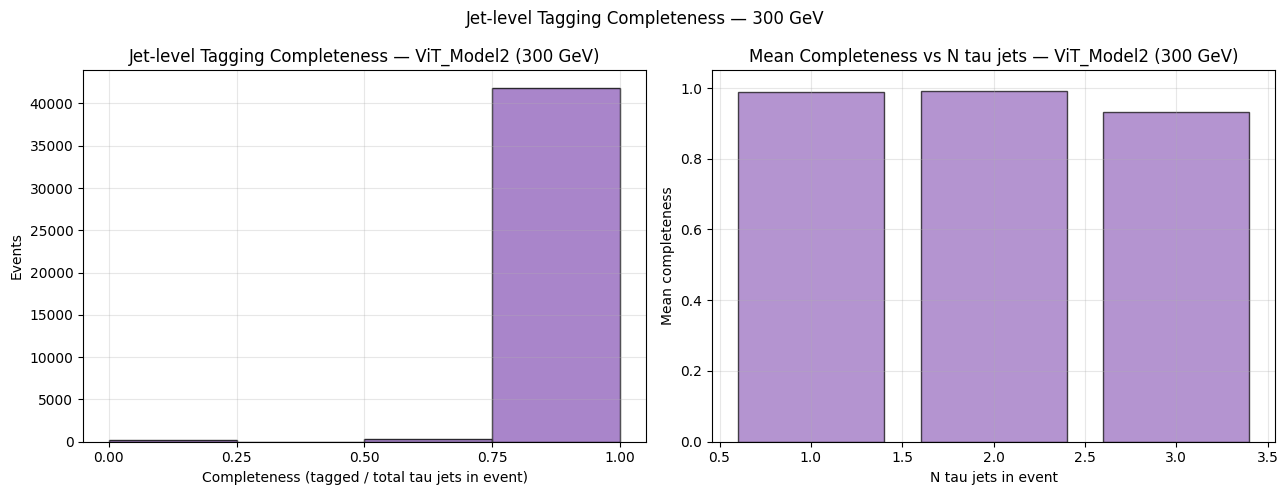


  Plots saved to: E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV\300GeV


In [ ]:
summary_rows = []
comp_roc     = {}   # ecm -> (tpr, fpr, auc)
comp_ev_eff  = {}   # ecm -> (bc, eff, err)
comp_pt_tau  = {}   # ecm -> (bc, eff, err)
 
for ecm in ENERGIES:
 
    rsep()
    rlog(f"  Evaluating {ecm} GeV")
    rsep()
 
    npz_path = TEST_DIR / f"jet_images_{ecm}GeV_test.npz"
    if not npz_path.exists():
        rlog(f"  ✗ File not found: {npz_path} — skipping")
        continue
 
    # ── load ──────────────────────────────────────────────────
    data      = np.load(npz_path)
    images    = data["images"]
    labels    = data["labels"]
    sample_id = data["sample_id"]
    jet_pt    = data["jet_pt"]
    event_id  = data["event_id"]
 
    tau_mask = sample_id == 0
    jj_mask  = sample_id == 1
    bb_mask  = sample_id == 2
 
    rlog(f"  Jets loaded  : {len(labels)}")
    rlog(f"  Signal (tau) : {tau_mask.sum()}")
    rlog(f"  Bkg (jj)     : {jj_mask.sum()}")
    rlog(f"  Bkg (bb)     : {bb_mask.sum()}")
 
    save_dir = RESULT_DIR / f"{ecm}GeV"
    save_dir.mkdir(parents=True, exist_ok=True)
 
    # ── inference ─────────────────────────────────────────────
    t0     = time.time()
    scores = run_inference(model, images, device)
    preds  = (scores > THRESHOLD).astype(int)
    rlog(f"  Inference : {time.time()-t0:.1f}s")
 
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, mask, color in [("tau", tau_mask, "tab:blue"),
                               ("jj",  jj_mask,  "tab:orange"),
                               ("bb",  bb_mask,  "tab:green")]:
        ax.hist(jet_pt[mask], bins=50, density=True, alpha=0.6,
                color=color, label=name)
    ax.set_xlabel("Jet $p_T$ [GeV]")
    ax.set_ylabel("Normalised")
    ax.set_title(f"pT Distribution — Test Set ({ecm} GeV)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f"pt_dist_{ecm}GeV.png", dpi=150)
    plt.show()
 
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(scores[labels == 1], bins=50, range=(0,1), density=True,
            alpha=0.6, color="tab:blue",  label="Signal (τ)")
    ax.hist(scores[labels == 0], bins=50, range=(0,1), density=True,
            alpha=0.6, color="tab:red",   label="Background")
    ax.axvline(THRESHOLD, color="black", ls="--", lw=1.2,
               label=f"threshold={THRESHOLD}")
    ax.set_xlabel("Model Output Score")
    ax.set_ylabel("Normalised")
    ax.set_title(f"Score Distribution — ViT_Model2 ({ecm} GeV)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f"score_dist_{ecm}GeV.png", dpi=150)
    plt.show()
 
    acc  = accuracy_score (labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score   (labels, preds, zero_division=0)
    f1   = f1_score       (labels, preds, zero_division=0)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc     = auc(fpr, tpr)
 
    rlog(f"\n  ── Metrics (threshold={THRESHOLD}) ──")
    rlog(f"  Accuracy  : {acc:.4f}")
    rlog(f"  Precision : {prec:.4f}")
    rlog(f"  Recall    : {rec:.4f}")
    rlog(f"  F1        : {f1:.4f}")
    rlog(f"  AUC       : {roc_auc:.4f}")
 
    auc_jj, auc_bb = None, None
    for bkg_name, bkg_sid in [("jj", 1), ("bb", 2)]:
        mask_b = tau_mask | (sample_id == bkg_sid)
        if mask_b.sum() > 0:
            f_b, t_b, _ = roc_curve(labels[mask_b], scores[mask_b])
            a_b = auc(f_b, t_b)
            if bkg_name == "jj": auc_jj = a_b
            else:                auc_bb = a_b
            rlog(f"  AUC τ vs {bkg_name} : {a_b:.4f}")
 
    comp_roc[ecm] = (tpr, fpr, roc_auc)
 
    cm   = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Background","Signal (τ)"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — ViT_Model2 ({ecm} GeV)")
    plt.tight_layout()
    plt.savefig(save_dir / f"confusion_matrix_{ecm}GeV.png", dpi=150)
    plt.show()
 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(tpr, 1.0 - fpr, lw=2, label=f"AUC = {roc_auc:.4f}")
    axes[0].set_xlabel("Signal Efficiency (TPR)")
    axes[0].set_ylabel("Background Rejection (1-FPR)")
    axes[0].set_title(f"Overall ROC — ViT_Model2 ({ecm} GeV)")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
    for ax, (bkg_name, bkg_sid) in zip(axes[1:], [("jj",1),("bb",2)]):
        mask_b      = tau_mask | (sample_id == bkg_sid)
        f_b, t_b, _ = roc_curve(labels[mask_b], scores[mask_b])
        ax.plot(t_b, 1.0 - f_b, lw=2, label=f"AUC = {auc(f_b,t_b):.4f}")
        ax.set_xlabel("Signal Efficiency (TPR)")
        ax.set_ylabel("Background Rejection (1-FPR)")
        ax.set_title(f"τ vs {bkg_name} — ViT_Model2 ({ecm} GeV)")
        ax.legend(); ax.grid(True, alpha=0.3)
 
    plt.suptitle(f"ROC Curves — ViT_Model2 ({ecm} GeV)", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_dir / f"roc_{ecm}GeV.png", dpi=150)
    plt.show()
 
    pt_bins = np.linspace(jet_pt.min(), jet_pt.max(), 20)
    colors_ = {"tau":"tab:blue","jj":"tab:orange","bb":"tab:green"}
    labels_ = {"tau":"τ efficiency","jj":"jj fake rate","bb":"bb fake rate"}
 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, mask) in zip(axes, [("tau",tau_mask),
                                        ("jj", jj_mask),
                                        ("bb", bb_mask)]):
        bc, eff, err = pt_binned_efficiency(jet_pt, scores, mask,
                                            THRESHOLD, pt_bins)
        ax.errorbar(bc, eff, yerr=err, fmt="o-",
                    color=colors_[name], capsize=3, lw=1.5)
        ax.set_xlabel("Jet $p_T$ [GeV]")
        ax.set_ylabel("Tagging Rate")
        ax.set_title(f"{labels_[name]} vs $p_T$ — ViT_Model2 ({ecm} GeV)")
        ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
        if name == "tau":
            comp_pt_tau[ecm] = (bc, eff, err)
 
    plt.suptitle(f"pT-Binned Tagging Efficiency — ViT_Model2 ({ecm} GeV)", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_dir / f"pt_efficiency_{ecm}GeV.png", dpi=150)
    plt.show()
 
    unique_events = np.unique(event_id[tau_mask])
    ev_lead_pt, ev_tagged = [], []
 
    for ev in unique_events:
        ev_sel = tau_mask & (event_id == ev)
        ev_pts = jet_pt[ev_sel]
        ev_sc  = scores[ev_sel]
        if len(ev_pts) == 0: continue
        ev_lead_pt.append(ev_pts.max())
        ev_tagged.append((ev_sc > THRESHOLD).any())
 
    ev_lead_pt = np.array(ev_lead_pt)
    ev_tagged  = np.array(ev_tagged)
 
    ev_pt_bins = np.linspace(ev_lead_pt.min(), ev_lead_pt.max(), 15)
    ev_bc, ev_eff, ev_err = pt_binned_efficiency(
        ev_lead_pt, ev_tagged.astype(float),
        np.ones(len(ev_lead_pt), dtype=bool), 0.5, ev_pt_bins)
 
    comp_ev_eff[ecm] = (ev_bc, ev_eff, ev_err)
 
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(ev_bc, ev_eff, yerr=ev_err, fmt="s-",
                color="tab:purple", capsize=3, lw=1.5,
                label="Event-wise τ tagging efficiency")
    ax.set_xlabel("Leading τ jet $p_T$ [GeV]")
    ax.set_ylabel("Event Tagging Efficiency")
    ax.set_title(f"Event-wise τ Tagging Efficiency — ViT_Model2 ({ecm} GeV)")
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f"event_tagging_efficiency_{ecm}GeV.png", dpi=150)
    plt.show()
 
    overall_ev_eff = ev_tagged.mean()
    rlog(f"\n  Event-tagging efficiency : "
         f"{overall_ev_eff:.4f}  ({ev_tagged.sum()}/{len(ev_tagged)} events)")
 
    completeness, n_tau_jets_per_event = [], []
 
    for ev in unique_events:
        ev_sel = tau_mask & (event_id == ev)
        ev_sc  = scores[ev_sel]
        n_tau  = ev_sel.sum()
        if n_tau == 0: continue
        completeness.append((ev_sc > THRESHOLD).sum() / n_tau)
        n_tau_jets_per_event.append(n_tau)
 
    completeness         = np.array(completeness)
    n_tau_jets_per_event = np.array(n_tau_jets_per_event)
 
    mean_comp = completeness.mean()
    frac_full = (completeness == 1.0).mean()
    frac_none = (completeness == 0.0).mean()
 
    rlog(f"\n  ── Jet-level tagging completeness ──")
    rlog(f"  Mean completeness          : {mean_comp:.4f}")
    rlog(f"  Fraction fully tagged      : {frac_full:.4f}  "
         f"({(completeness==1.0).sum()}/{len(completeness)} events)")
    rlog(f"  Fraction not tagged at all : {frac_none:.4f}  "
         f"({(completeness==0.0).sum()}/{len(completeness)} events)")
 
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
    axes[0].hist(completeness, bins=[0, 0.25, 0.5, 0.75, 1.001],
                 edgecolor="black", color="tab:purple", alpha=0.8)
    axes[0].set_xlabel("Completeness (tagged / total tau jets in event)")
    axes[0].set_ylabel("Events")
    axes[0].set_title(f"Jet-level Tagging Completeness — ViT_Model2 ({ecm} GeV)")
    axes[0].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    axes[0].grid(True, alpha=0.3)
 
    for n in sorted(np.unique(n_tau_jets_per_event)):
        sel = n_tau_jets_per_event == n
        axes[1].bar(n, completeness[sel].mean(), color="tab:purple",
                    alpha=0.7, edgecolor="black")
    axes[1].set_xlabel("N tau jets in event")
    axes[1].set_ylabel("Mean completeness")
    axes[1].set_title(f"Mean Completeness vs N tau jets — ViT_Model2 ({ecm} GeV)")
    axes[1].set_ylim(0, 1.05); axes[1].grid(True, alpha=0.3)
 
    plt.suptitle(f"Jet-level Tagging Completeness — {ecm} GeV", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_dir / f"completeness_{ecm}GeV.png", dpi=150)
    plt.show()
 
    summary_rows.append({
        "energy_GeV"       : ecm,
        "n_jets"           : len(labels),
        "accuracy"         : round(acc,       4),
        "precision"        : round(prec,      4),
        "recall"           : round(rec,       4),
        "f1"               : round(f1,        4),
        "auc_overall"      : round(roc_auc,   4),
        "auc_tau_jj"       : round(auc_jj,    4) if auc_jj else None,
        "auc_tau_bb"       : round(auc_bb,    4) if auc_bb else None,
        "ev_tag_eff"       : round(float(overall_ev_eff), 4),
        "mean_completeness": round(float(mean_comp),      4),
        "frac_fully_tagged": round(float(frac_full),      4),
    })
 
    rlog(f"\n  Plots saved to: {save_dir}")

  SUMMARY — ViT_Model2 across all energies
 energy_GeV  n_jets  accuracy  precision  recall     f1  auc_overall  auc_tau_jj  auc_tau_bb  ev_tag_eff  mean_completeness  frac_fully_tagged
        100  224164    0.9693     0.9262  0.9258 0.9260       0.9937      0.9896      0.9977      0.9444             0.9230             0.9016
        125  239720    0.9774     0.9407  0.9537 0.9472       0.9963      0.9939      0.9986      0.9665             0.9520             0.9373
        150  258279    0.9820     0.9499  0.9660 0.9579       0.9976      0.9959      0.9992      0.9762             0.9644             0.9527
        200  277990    0.9872     0.9589  0.9815 0.9701       0.9986      0.9976      0.9995      0.9873             0.9806             0.9739
        250  291519    0.9891     0.9620  0.9868 0.9742       0.9989      0.9983      0.9996      0.9916             0.9864             0.9812
        300  302466    0.9906     0.9644  0.9908 0.9774       0.9991      0.9986      0.9996      0

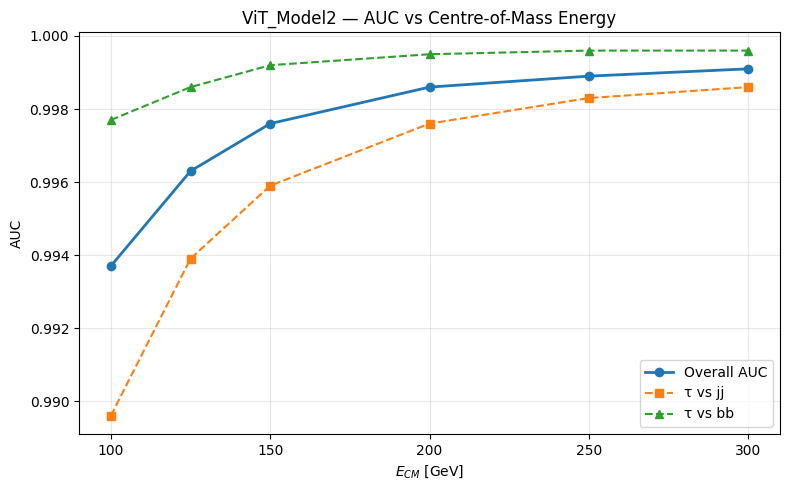

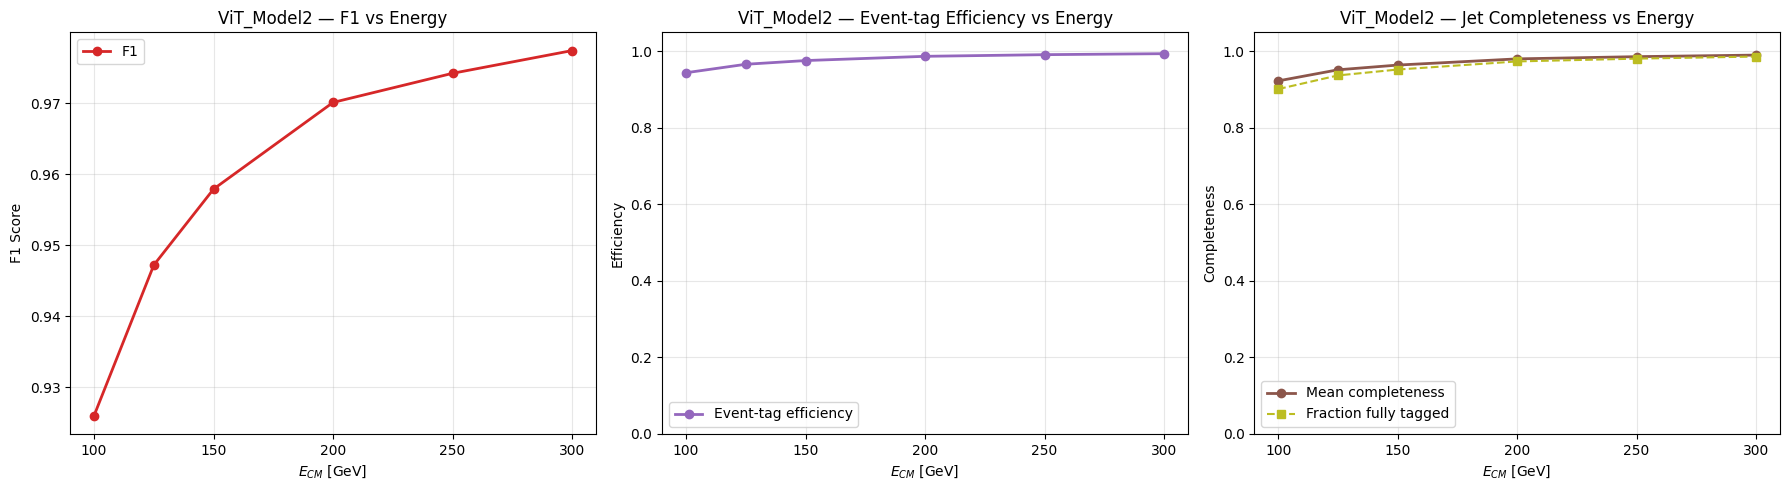

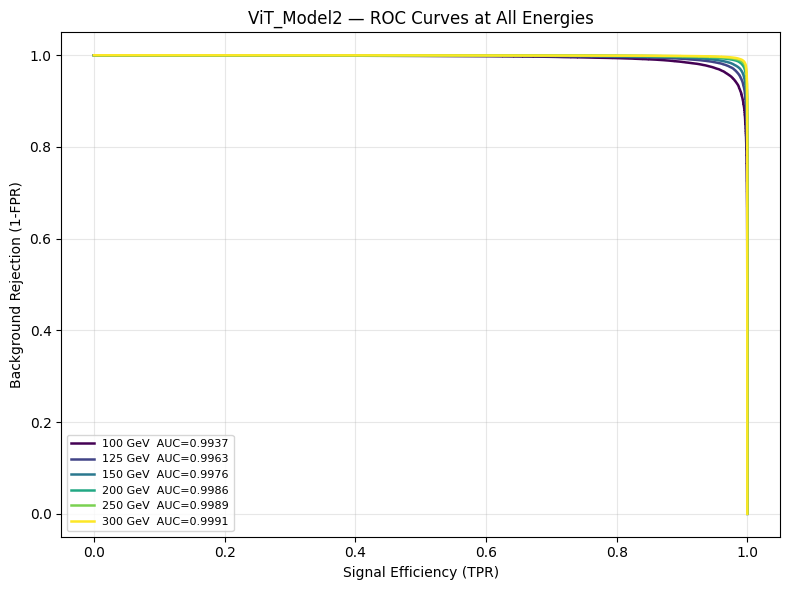

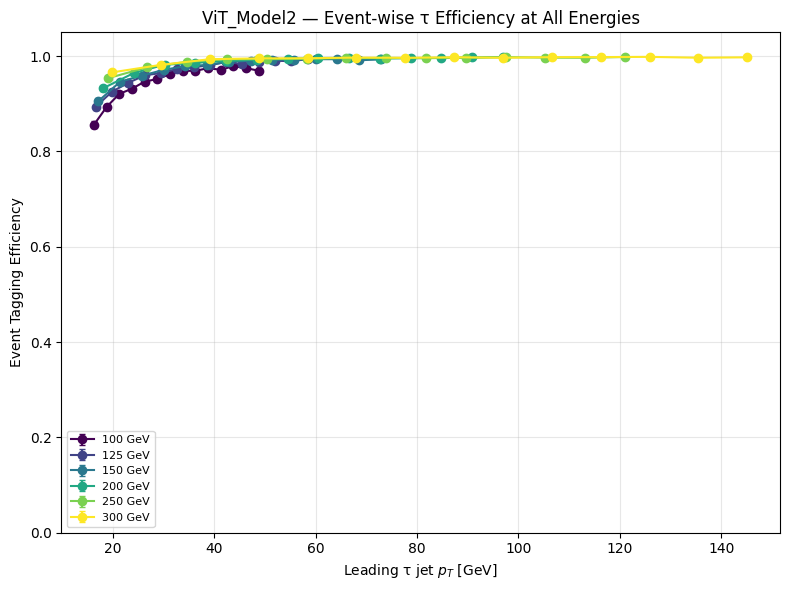

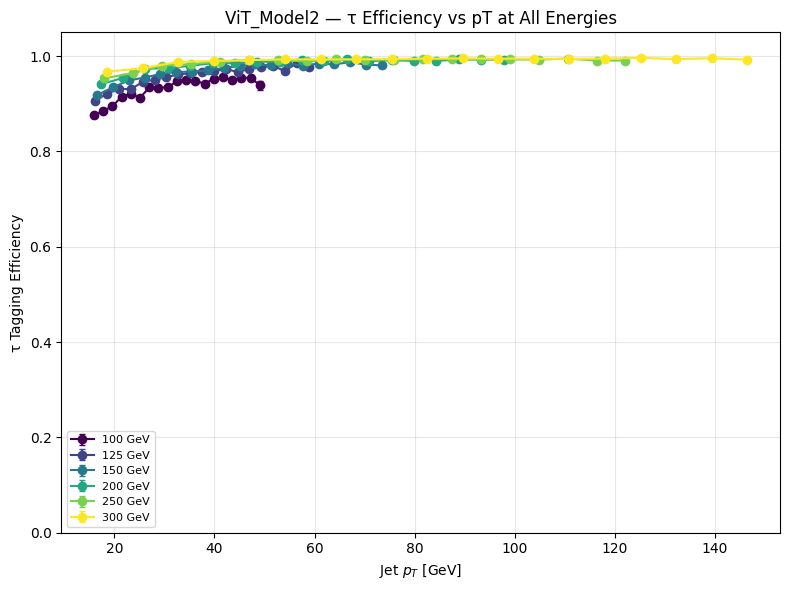


Log saved to    : E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV\evaluation_log.txt
All results in  : E:\Python\MSc_Project_Upgrade\results_analysis\vit\test_results_model2_250GeV


In [ ]:
# SUMMARY TABLE 

rsep()
rlog("  SUMMARY — ViT_Model2 across all energies")
rsep()
 
if summary_rows:
    df_vit = pd.DataFrame(summary_rows)
    rlog(df_vit.to_string(index=False))
 
    csv_path = RESULT_DIR / "summary_vit.csv"
    df_vit.to_csv(csv_path, index=False)
    rlog(f"\n  CSV saved to: {csv_path}")
 
    cmap   = plt.cm.viridis
    colors = [cmap(i / max(len(comp_roc)-1, 1)) for i in range(len(comp_roc))]
 
    # C1 — AUC vs energy
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df_vit["energy_GeV"], df_vit["auc_overall"], "o-",
            lw=2, label="Overall AUC", color="tab:blue")
    if df_vit["auc_tau_jj"].notna().all():
        ax.plot(df_vit["energy_GeV"], df_vit["auc_tau_jj"], "s--",
                lw=1.5, label="τ vs jj", color="tab:orange")
    if df_vit["auc_tau_bb"].notna().all():
        ax.plot(df_vit["energy_GeV"], df_vit["auc_tau_bb"], "^--",
                lw=1.5, label="τ vs bb", color="tab:green")
    ax.set_xlabel("$E_{CM}$ [GeV]"); ax.set_ylabel("AUC")
    ax.set_title("ViT_Model2 — AUC vs Centre-of-Mass Energy")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "auc_vs_energy_vit.png", dpi=150)
    plt.show()
 
    # C2 — F1 + event efficiency + completeness vs energy
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
    axes[0].plot(df_vit["energy_GeV"], df_vit["f1"], "o-",
                 lw=2, color="tab:red", label="F1")
    axes[0].set_xlabel("$E_{CM}$ [GeV]"); axes[0].set_ylabel("F1 Score")
    axes[0].set_title("ViT_Model2 — F1 vs Energy")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_locator(ticker.MultipleLocator(50))
 
    axes[1].plot(df_vit["energy_GeV"], df_vit["ev_tag_eff"], "o-",
                 lw=2, color="tab:purple", label="Event-tag efficiency")
    axes[1].set_xlabel("$E_{CM}$ [GeV]"); axes[1].set_ylabel("Efficiency")
    axes[1].set_title("ViT_Model2 — Event-tag Efficiency vs Energy")
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_locator(ticker.MultipleLocator(50))
 
    axes[2].plot(df_vit["energy_GeV"], df_vit["mean_completeness"], "o-",
                 lw=2, color="tab:brown", label="Mean completeness")
    axes[2].plot(df_vit["energy_GeV"], df_vit["frac_fully_tagged"], "s--",
                 lw=1.5, color="tab:olive", label="Fraction fully tagged")
    axes[2].set_xlabel("$E_{CM}$ [GeV]"); axes[2].set_ylabel("Completeness")
    axes[2].set_title("ViT_Model2 — Jet Completeness vs Energy")
    axes[2].set_ylim(0, 1.05); axes[2].legend(); axes[2].grid(True, alpha=0.3)
    axes[2].xaxis.set_major_locator(ticker.MultipleLocator(50))
 
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "metrics_vs_energy_vit.png", dpi=150)
    plt.show()
 
    # C3 — ROC overlay all energies
    fig, ax = plt.subplots(figsize=(8, 6))
    for (ecm_r, (tpr_r, fpr_r, a_r)), col in zip(sorted(comp_roc.items()), colors):
        ax.plot(tpr_r, 1.0 - fpr_r, lw=1.8, color=col,
                label=f"{ecm_r} GeV  AUC={a_r:.4f}")
    ax.set_xlabel("Signal Efficiency (TPR)")
    ax.set_ylabel("Background Rejection (1-FPR)")
    ax.set_title("ViT_Model2 — ROC Curves at All Energies")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "roc_all_energies_vit.png", dpi=150)
    plt.show()
 
    # C4 — Event-tagging efficiency overlay
    fig, ax = plt.subplots(figsize=(8, 6))
    for (ecm_e, (bc_e, eff_e, err_e)), col in zip(
            sorted(comp_ev_eff.items()), colors):
        ax.errorbar(bc_e, eff_e, yerr=err_e, fmt="o-", color=col,
                    capsize=2, lw=1.5, label=f"{ecm_e} GeV")
    ax.set_xlabel("Leading τ jet $p_T$ [GeV]")
    ax.set_ylabel("Event Tagging Efficiency")
    ax.set_title("ViT_Model2 — Event-wise τ Efficiency at All Energies")
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "event_eff_all_energies_vit.png", dpi=150)
    plt.show()
 
    # C5 — pT-binned tau efficiency overlay
    fig, ax = plt.subplots(figsize=(8, 6))
    for (ecm_p, (bc_p, eff_p, err_p)), col in zip(
            sorted(comp_pt_tau.items()), colors):
        ax.errorbar(bc_p, eff_p, yerr=err_p, fmt="o-", color=col,
                    capsize=2, lw=1.5, label=f"{ecm_p} GeV")
    ax.set_xlabel("Jet $p_T$ [GeV]")
    ax.set_ylabel("τ Tagging Efficiency")
    ax.set_title("ViT_Model2 — τ Efficiency vs pT at All Energies")
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "pt_tau_eff_all_energies_vit.png", dpi=150)
    plt.show()
  

log_path = RESULT_DIR / "evaluation_log.txt"
with open(log_path, "w", encoding="utf-8") as f:
    f.write("\n".join(log_lines))
 
rlog(f"\nLog saved to    : {log_path}")
rlog(f"All results in  : {RESULT_DIR}")